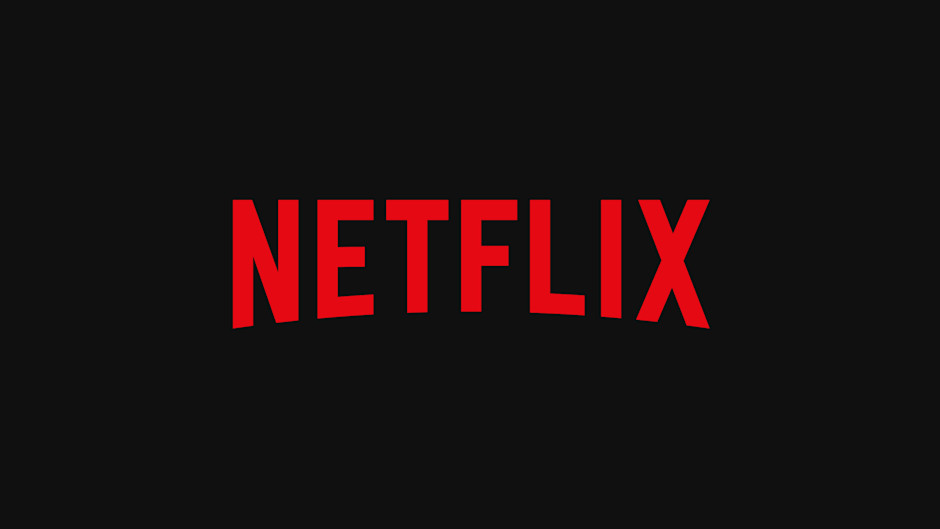

# 📑 Table of Contents

1. Introduction
2. Business Objective
3. Dataset Information
4. Data Understanding
5. Data Cleaning
6. Exploratory Data Analysis
   - Distribution of Movies and TV Shows
   - Release Year Analysis
   - Top Producing Countries
   - Most Popular Genres
   - Content Ratings
   - Movie Duration Analysis
   - Monthly Content Additions
   - Movies vs TV Shows by Country
7. Key Business Insights
8. Business Recommendations
9. Conclusion

## 🔄 Project Workflow

Dataset Collection

↓

Data Understanding

↓

Data Cleaning

↓

Exploratory Data Analysis

↓

Business Insights

↓

Recommendations

↓

Conclusion

# 📺 Netflix Content Analysis: Exploring Trends, Genres, and Global Content Strategy Using Python

## 📌 Introduction

### Netflix has transformed the entertainment industry by becoming one of the world's leading streaming platforms. With thousands of movies and TV shows from different countries, genres, and release periods, understanding its content library can reveal valuable insights into content distribution, production trends, and audience targeting.

* This project performs an Exploratory Data Analysis (EDA) on the Netflix Titles dataset using Python. The objective is to uncover meaningful patterns through data visualization and generate business insights that could support content strategy and decision-making.

## 🎯 Business Objective

The primary objective of this project is to analyze Netflix's content catalog and answer the following business questions:

- What type of content dominates Netflix's catalog?
- How has Netflix's content library evolved over the years?
- Which countries contribute the most content?
- Which genres are the most popular?
- What content ratings are most common?
- How does Netflix's movie duration vary?
- During which months is the most content added?

The insights generated from this analysis can help understand Netflix's content strategy and identify trends in its global content distribution.

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

## 📂 Dataset Information

**Dataset Name:** Netflix Movies and TV Shows

**Source:** Kaggle

**Records:** 8,807

**Features:** 12

**Description:**
This dataset contains information about movies and TV shows available on Netflix, including title, director, cast, country, release year, rating, duration, genre, and date added.

## 📂 Loading the Dataset

In [29]:
netflix_data = pd.read_csv("netflix_titles.csv")

## 🔍 Data Understanding

#### Before performing any analysis, it is important to understand the structure of the dataset, including the number of records, available features, and data types. This helps identify potential data quality issues that need to be addressed before analysis.

In [30]:
netflix_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [31]:
netflix_data.shape

(6234, 12)

In [33]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


## 🧹 Data Cleaning

#### Data cleaning ensures that the dataset is complete, consistent, and suitable for analysis. In this step, missing values and duplicate records are identified and handled appropriately.

In [34]:
netflix_data.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

In [35]:
(netflix_data.isnull().sum()/len(netflix_data))*100

show_id          0.000000
type             0.000000
title            0.000000
director        31.584857
cast             9.143407
country          7.635547
date_added       0.176452
release_year     0.000000
rating           0.160411
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [36]:
netflix_data.duplicated().sum()

np.int64(0)

In [37]:
netflix_data['director'] = netflix_data['director'].fillna('Unknown')
netflix_data['cast'] = netflix_data['cast'].fillna('Unknown')
netflix_data['country'] = netflix_data['country'].fillna('Unknown')

netflix_data = netflix_data.dropna(subset=['date_added','rating'])

In [38]:
netflix_data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## 1. Distribution of Movies and TV Shows

### 📌 Business Question

What type of content dominates Netflix's catalog?

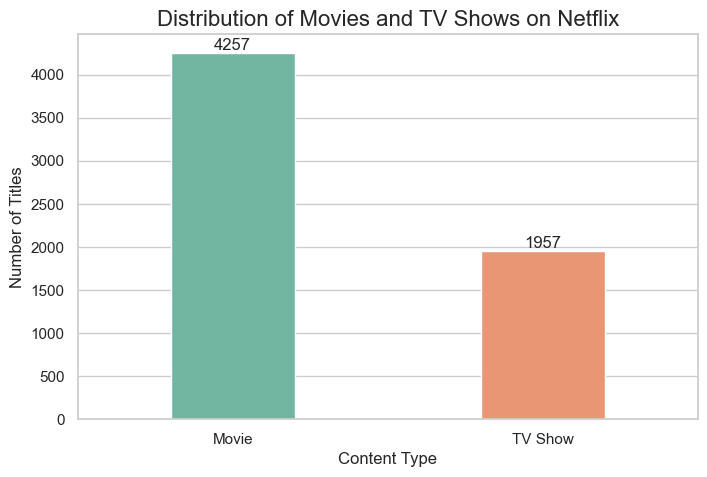

In [58]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=netflix_data,
    x='type',
    hue='type',
    legend=False,
    width=0.4
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.savefig(
    "images/movies_vs_tvshows.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

### 🔍 Key Findings

- Movies significantly outnumber TV Shows in Netflix's catalog.
- This indicates that Netflix has historically focused on expanding its movie library.

### 💼 Business Insight

Movies require lower long-term production commitments compared to multi-season TV Shows. A larger movie catalog enables Netflix to offer greater variety across genres and audiences.

### 🎯 Recommendation

Netflix should continue maintaining a diverse movie library while strategically increasing investments in high-quality TV series that can improve long-term subscriber retention.

## 2. Release Year Distribution

### 📌 Business Question

How has Netflix's content catalog evolved over time?

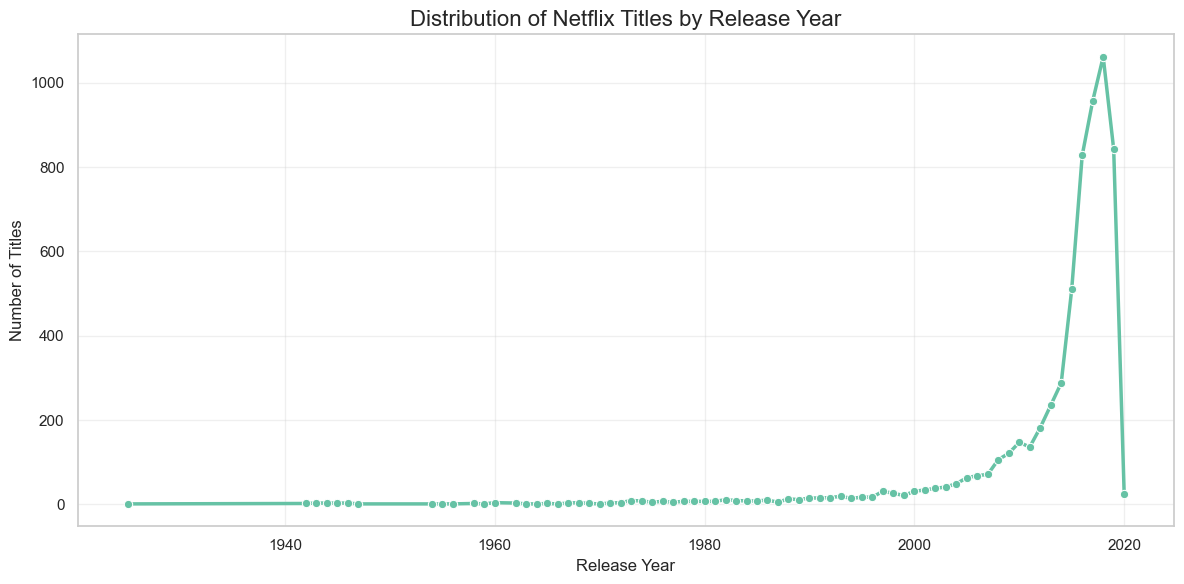

In [59]:
yearly_content = (
    netflix_data['release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=yearly_content.index,
    y=yearly_content.values,
    marker='o',
    linewidth=2.5
)

plt.title("Distribution of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "images/release_year_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 🔍 Key Findings

- The number of titles released increased significantly after 2015.
- The dataset also contains classic titles released before 1995, although they represent a small portion of the catalog.
- The highest concentration of titles appears between 2016 and 2020.

### 💼 Business Insight

Netflix's catalog reflects both historical licensing of classic content and a strong emphasis on acquiring or producing modern titles during its global expansion.

### 🎯 Recommendation

Netflix should continue balancing classic content with new releases to serve diverse audience preferences while sustaining growth through original productions.

## 3. Top 10 Content Producing Countries

### 📌 Business Question

Which countries contribute the most content to Netflix?

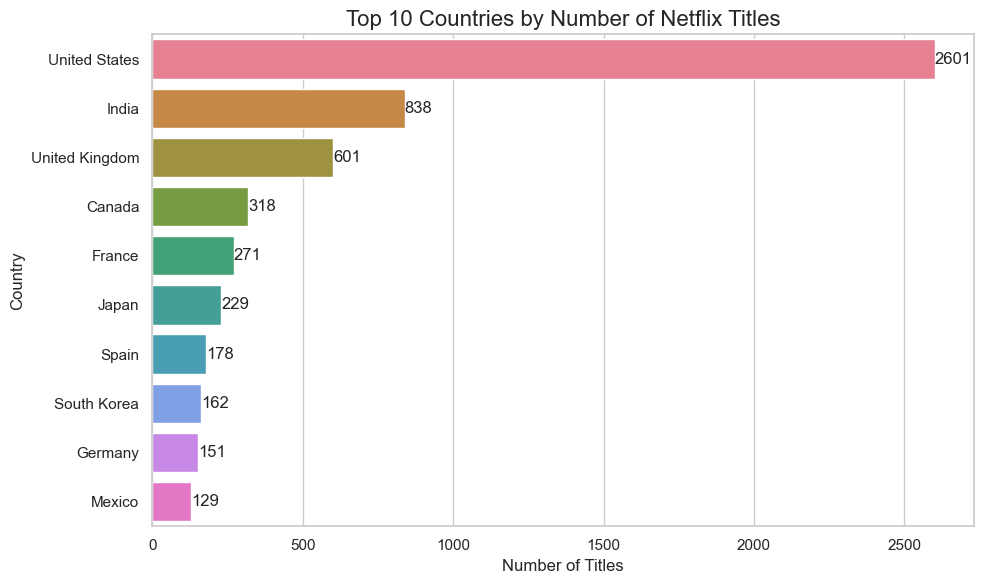

In [60]:
top_country = (
    netflix_data['country']
    .str.split(',')
    .explode()
    .str.strip()
)

top_country = (
    top_country[top_country != 'Unknown']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_country.values,
    y=top_country.index,
    hue=top_country.index,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig(
    "images/top_producing_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 🔍 Key Findings

- The United States contributes the largest number of titles.
- India ranks among the leading contributors.
- Netflix sources content from multiple countries, highlighting its global presence.

### 💼 Business Insight

Netflix relies heavily on major entertainment markets while continuously expanding its international content portfolio to appeal to diverse audiences.

### 🎯 Recommendation

Netflix should continue investing in regional content production to strengthen its presence in emerging markets while maintaining strong partnerships in established content-producing countries.

## 4. Most Popular Genres

### 📌 Business Question

Which genres dominate Netflix's content library?

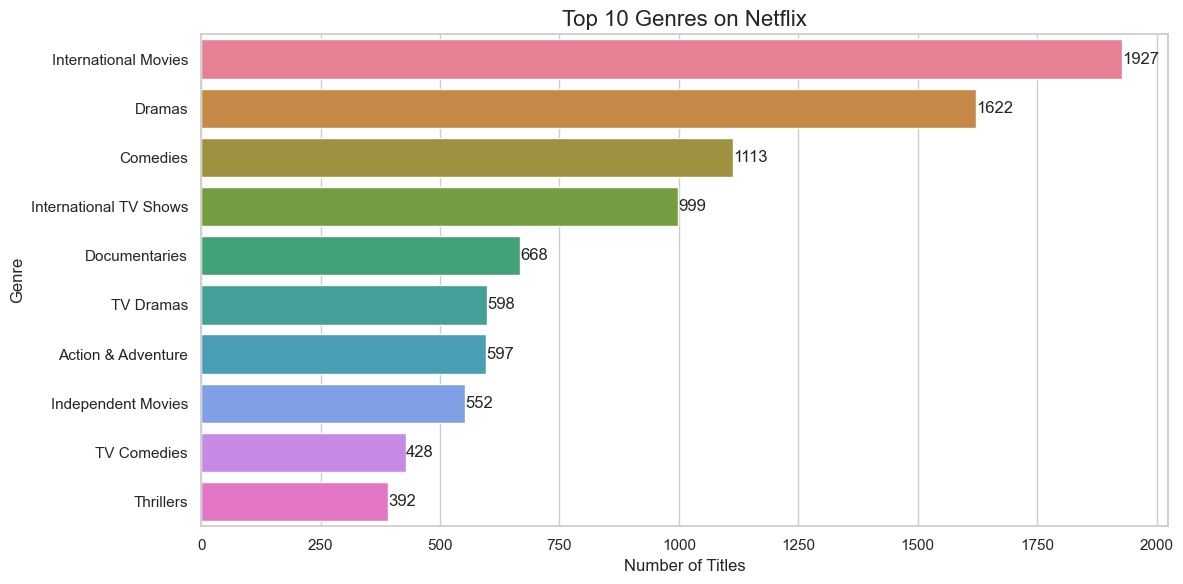

In [61]:
top_genres = (
    netflix_data['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.savefig(
    "images/top_genres.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 🔍 Key Findings

- International Movies, Dramas, and Comedies are among the most represented genres.
- Netflix offers content across a broad range of genres.

### 💼 Business Insight

The popularity of international and drama content highlights Netflix's strategy of serving a global audience with diverse entertainment preferences.

### 🎯 Recommendation

Netflix should continue investing in internationally successful genres while identifying emerging genres with growth potential.

## 5. Content Ratings

### 📌 Business Question

Which audience age groups are primarily targeted by Netflix?

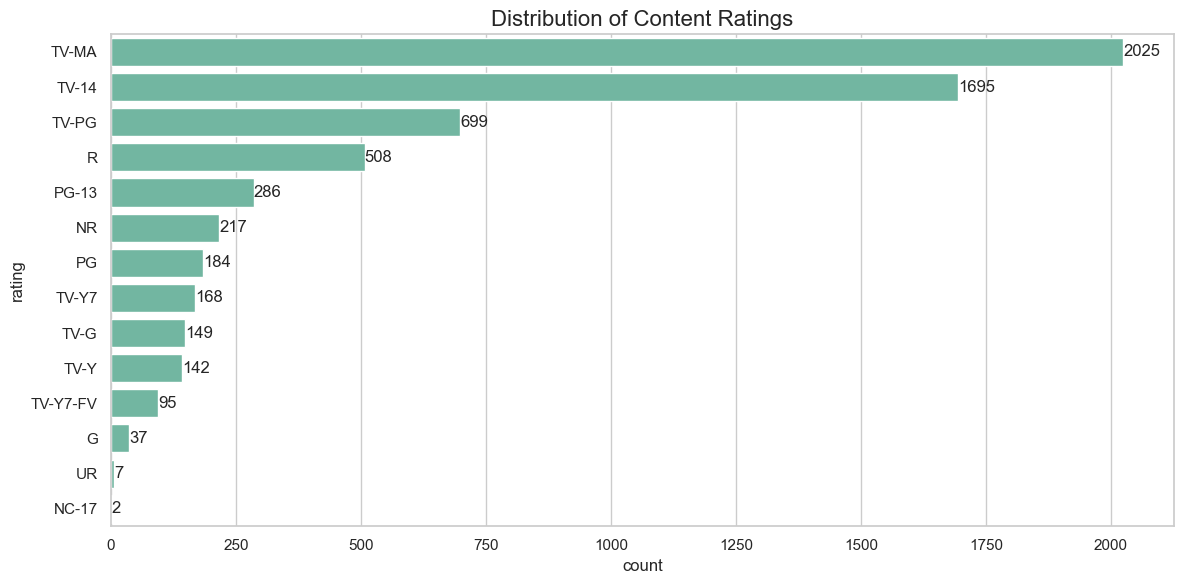

In [44]:
plt.figure(figsize=(12,6))

order = netflix_data['rating'].value_counts().index

ax = sns.countplot(
    data=netflix_data,
    y='rating',
    order=order
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Content Ratings")

plt.tight_layout()
plt.show()

### 🔍 Key Findings

- TV-MA is the most common content rating.
- Netflix offers content for all age groups but has a strong focus on mature audiences.

### 💼 Business Insight

The dominance of mature-rated content suggests that Netflix primarily targets adult viewers while maintaining a balanced catalog for younger audiences.

### 🎯 Recommendation

Continue producing mature content while expanding family-friendly programming to increase household engagement.

## 6. Movie Duration Analysis

### 📌 Business Question

What is the typical duration of movies available on Netflix?

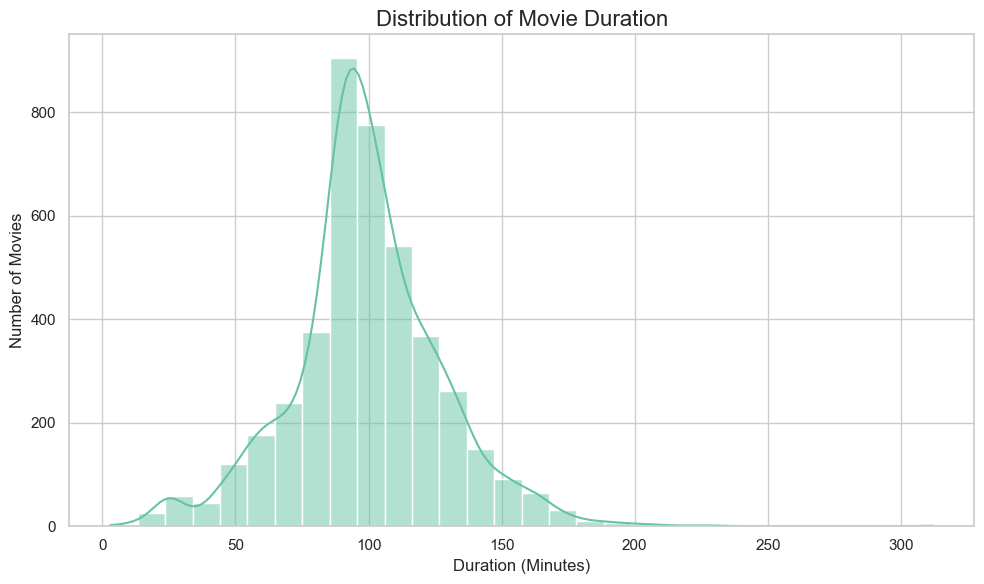

In [45]:
movies = netflix_data[netflix_data['type'] == 'Movie'].copy()

movies['duration'] = (
    movies['duration']
    .str.replace(' min','', regex=False)
    .astype(int)
)

plt.figure(figsize=(10,6))

sns.histplot(
    movies['duration'],
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

### 🔍 Key Findings

- Most movies have a runtime between 80 and 120 minutes.

### 💼 Business Insight

Netflix's movie catalog closely follows the standard feature-length duration preferred by audiences.

### 🎯 Recommendation

Continue producing feature-length films while experimenting with shorter formats for mobile-first viewers.

## 7. Monthly Content Additions

### 📌 Business Question

During which months does Netflix add the most content?

C:\Users\Satyam Singh\AppData\Local\Temp\ipykernel_17320\664314174.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_data['date_added'] = pd.to_datetime(


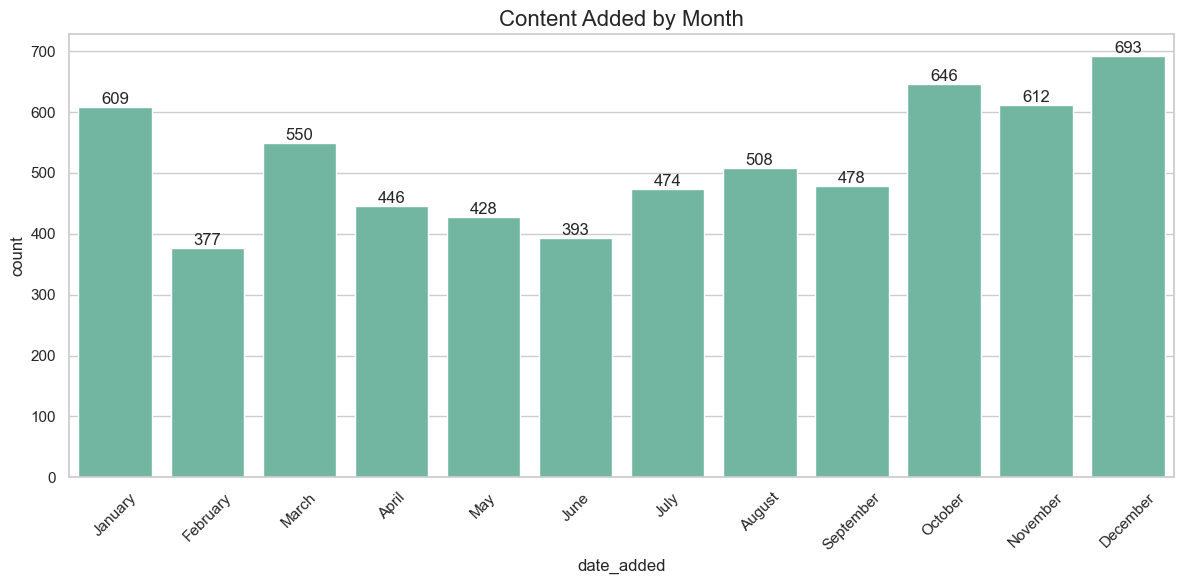

In [46]:
netflix_data['date_added'] = pd.to_datetime(
    netflix_data['date_added'].str.strip(),
    format='mixed'
)

monthly = netflix_data['date_added'].dt.month_name()

order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

plt.figure(figsize=(12,6))

ax = sns.countplot(
    x=monthly,
    order=order
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)

plt.title("Content Added by Month")

plt.tight_layout()
plt.show()

### 🔍 Key Findings

- Netflix adds content throughout the year, with some months showing higher activity.

### 💼 Business Insight

The distribution suggests a planned content release strategy rather than concentrating releases in a single season.

### 🎯 Recommendation

Analyze subscriber engagement alongside monthly releases to optimize future content scheduling.

## 8. Movies vs TV Shows by Country

### 📌 Business Question

How does the distribution of Movies and TV Shows vary across major content-producing countries?

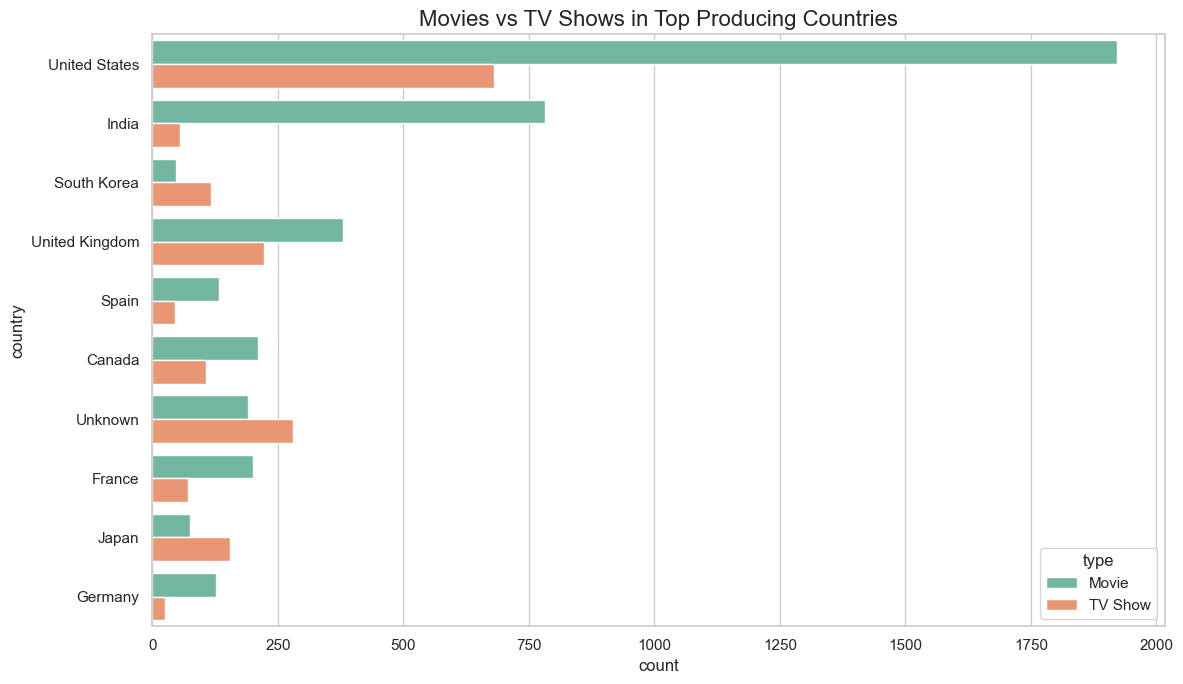

In [56]:
country_type = netflix_data.copy()

country_type['country'] = country_type['country'].str.split(',')

country_type = country_type.explode('country')

country_type['country'] = country_type['country'].str.strip()

top = country_type['country'].value_counts().head(10).index

plt.figure(figsize=(12,7))

sns.countplot(
    data=country_type[country_type['country'].isin(top)],
    y='country',
    hue='type'
)

plt.title("Movies vs TV Shows in Top Producing Countries")

plt.tight_layout()
plt.show()


## 9. Top 10 Directors on Netflix

### 📌 Business Question

Which directors have the highest number of titles available on Netflix?

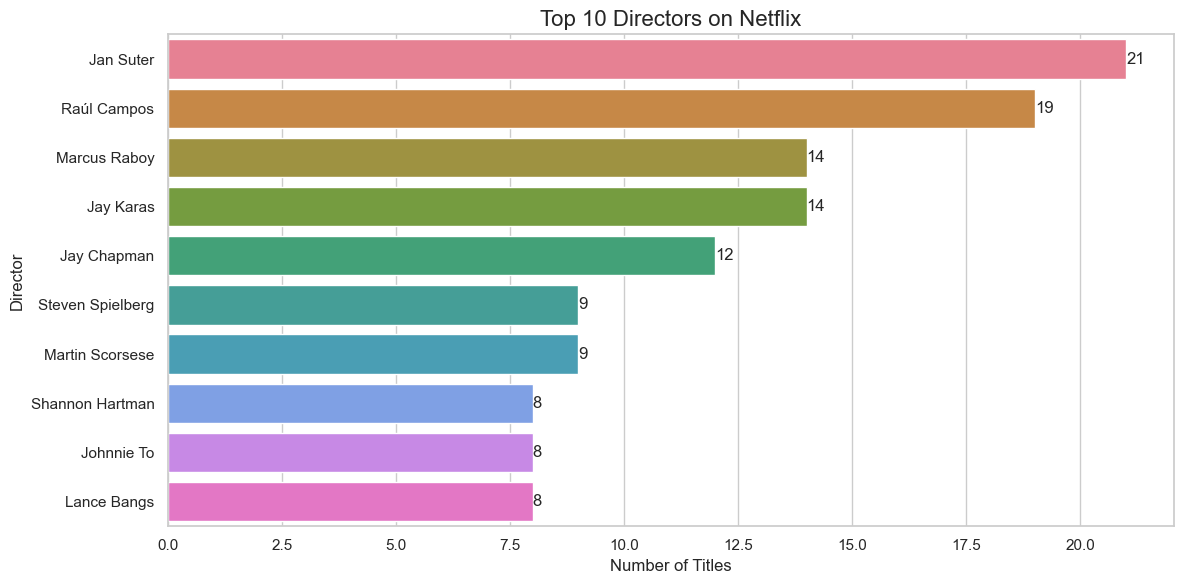

In [62]:
top_directors = (
    netflix_data[netflix_data['director'] != 'Unknown']['director']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.tight_layout()
plt.savefig(
    "images/top_directors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 🔍 Key Findings

- A small group of directors has multiple titles available on Netflix.
- Some directors have built long-term collaborations with the platform.

### 💼 Business Insight

Frequent collaborations with successful directors help Netflix maintain consistent content quality and strengthen audience trust.

### 🎯 Recommendation

Netflix should continue partnering with high-performing directors while also supporting emerging filmmakers to diversify its content portfolio.

## 10. Top 10 Actors on Netflix

### 📌 Business Question

Which actors appear most frequently in Netflix's catalog?

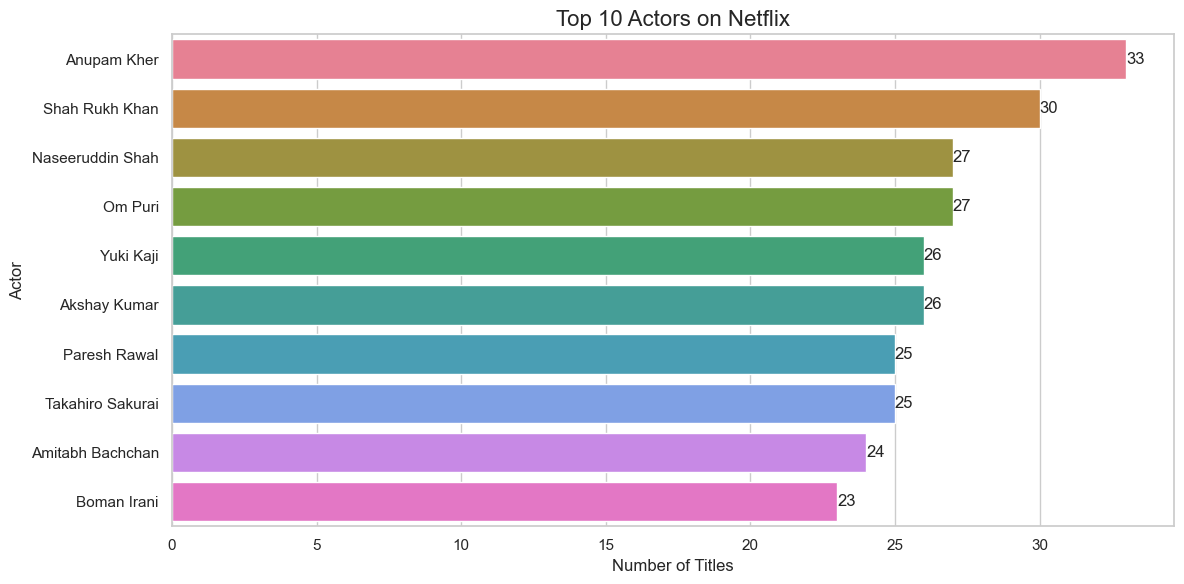

In [63]:
top_actors = (
    netflix_data[netflix_data['cast'] != 'Unknown']['cast']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_actors.values,
    y=top_actors.index,
    hue=top_actors.index,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Actors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Actor")

plt.tight_layout()
plt.savefig(
    "images/top_actors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 🔍 Key Findings

- Several actors appear repeatedly across Netflix's catalog.
- These actors contribute to a wide variety of movies and TV shows.

### 💼 Business Insight

Popular actors can increase audience engagement and content discoverability, making them valuable assets for streaming platforms.

### 🎯 Recommendation

Netflix should continue collaborating with well-established actors while promoting new talent to broaden its audience appeal.

# 📈 Key Business Insights

- Movies account for the majority of Netflix's content library.
- Netflix's catalog expanded rapidly after 2015, reflecting its global growth.
- The United States and India are among the largest contributors to Netflix's catalog.
- International Movies and Dramas dominate the platform's genre distribution.
- TV-MA is the most common content rating, indicating a strong focus on mature audiences.
- Most movies have a runtime between 80 and 120 minutes.
- Netflix maintains a consistent content release strategy throughout the year.

# 💡 Business Recommendations

- Increase investment in regional content production to strengthen global market presence.
- Continue balancing movies with high-quality TV series to improve subscriber retention.
- Expand successful international genres into emerging markets.
- Use audience engagement data to optimize monthly content release schedules.
- Explore opportunities in underrepresented genres to diversify the content portfolio.

# ✅ Conclusion

This project analyzed Netflix's content catalog using Exploratory Data Analysis (EDA) techniques in Python. The findings reveal that Netflix has built a globally diverse content library dominated by movies, with significant growth occurring after 2015. The platform continues to invest in international content while targeting a broad audience through a variety of genres and ratings. These insights can support strategic decisions related to content acquisition, production, and audience engagement.